In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/train (1).csv
/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques/test (1).csv


In [2]:
# Load Libraries

# Data handling
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#ML
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.feature_selection import mutual_info_regression
import shap
from sklearn.metrics import silhouette_score

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_rel


In [3]:
# Load Data

data_path = '/kaggle/input/datasets/rishitaverma02/house-prices-advanced-regression-techniques'

# Load datasets
train = pd.read_csv(f'{data_path}/train (1).csv')
test = pd.read_csv(f'{data_path}/test (1).csv')
sample = pd.read_csv(f'{data_path}/sample_submission.csv')

# Display shapes
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)
print("Sample Shape:", sample.shape)

# Preview
train.head()


Train Shape: (1460, 81)
Test Shape : (1459, 80)
Sample Shape: (1459, 2)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Missing Values ---
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


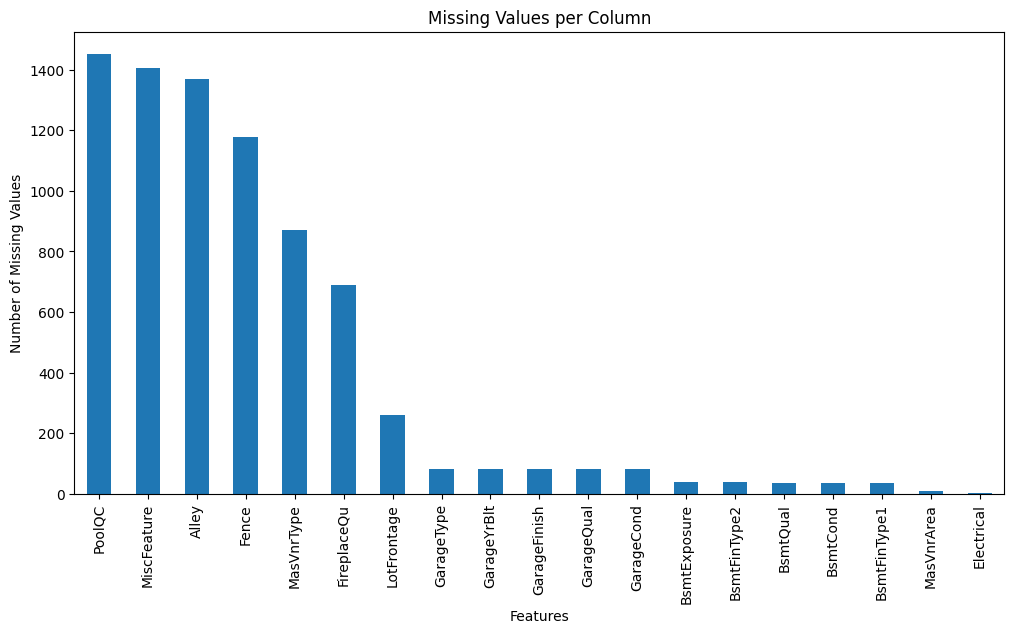


--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_16/3541617771.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


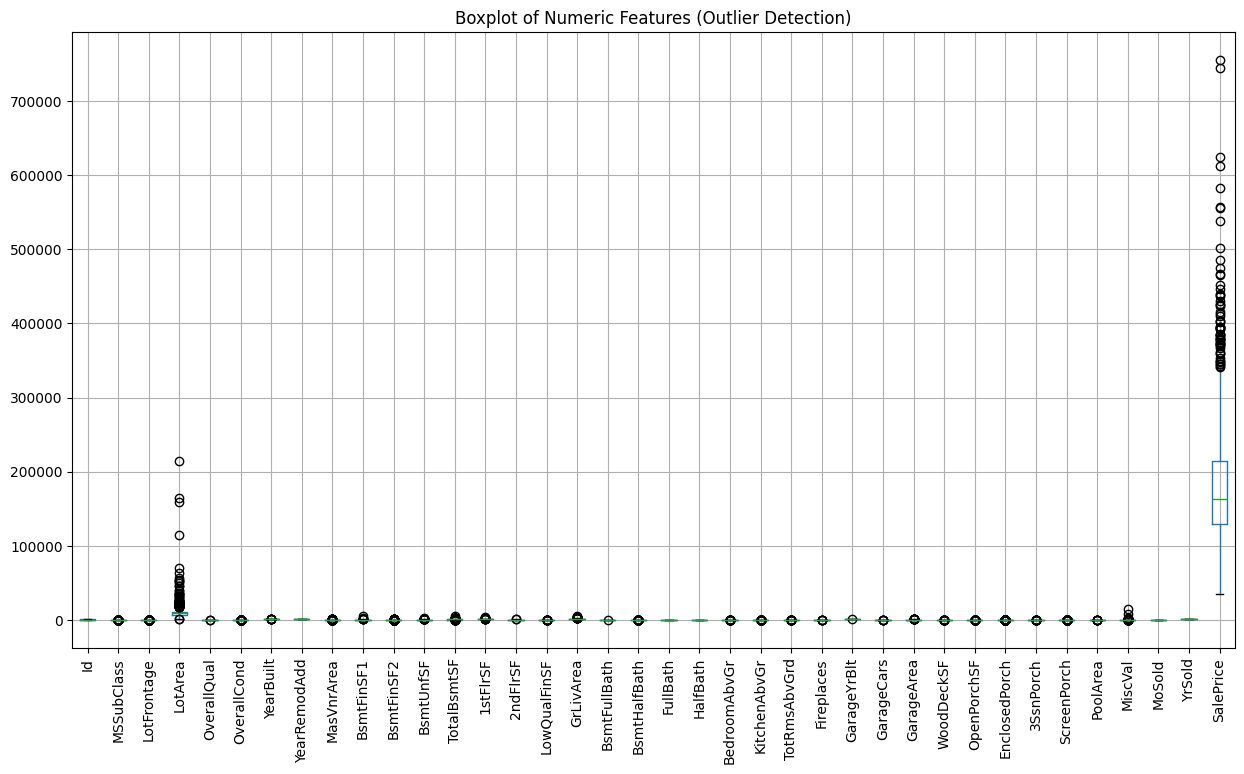

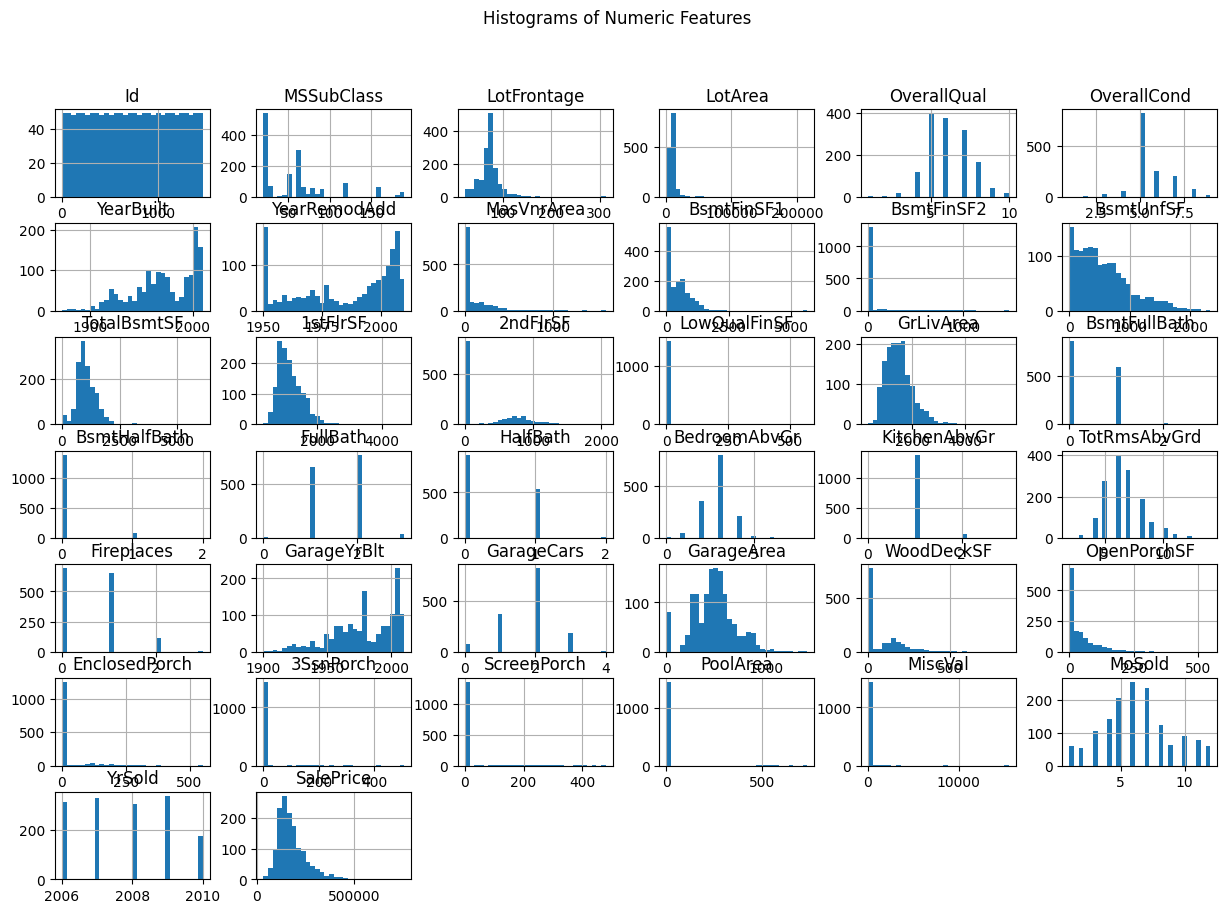

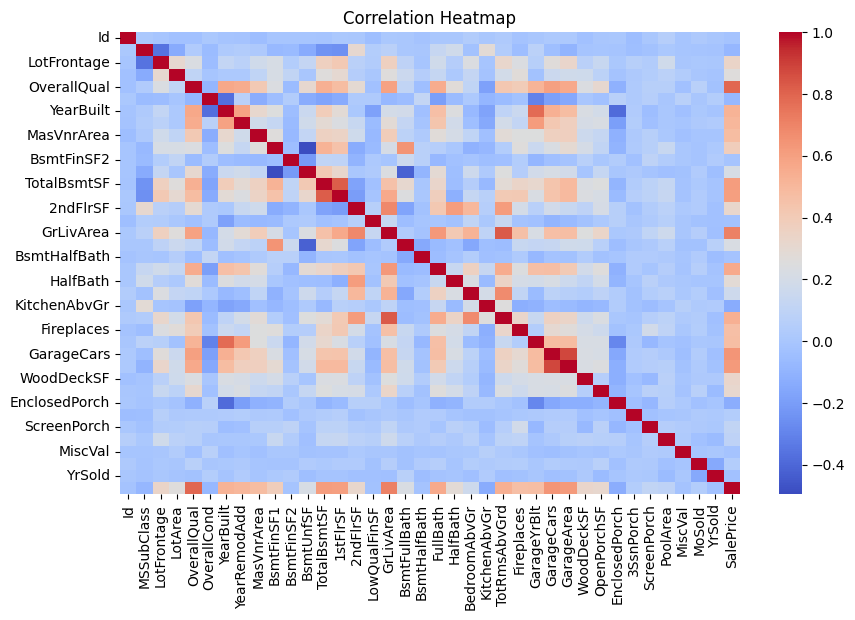

Outliers removed. Remaining rows: 557
After removing outliers:


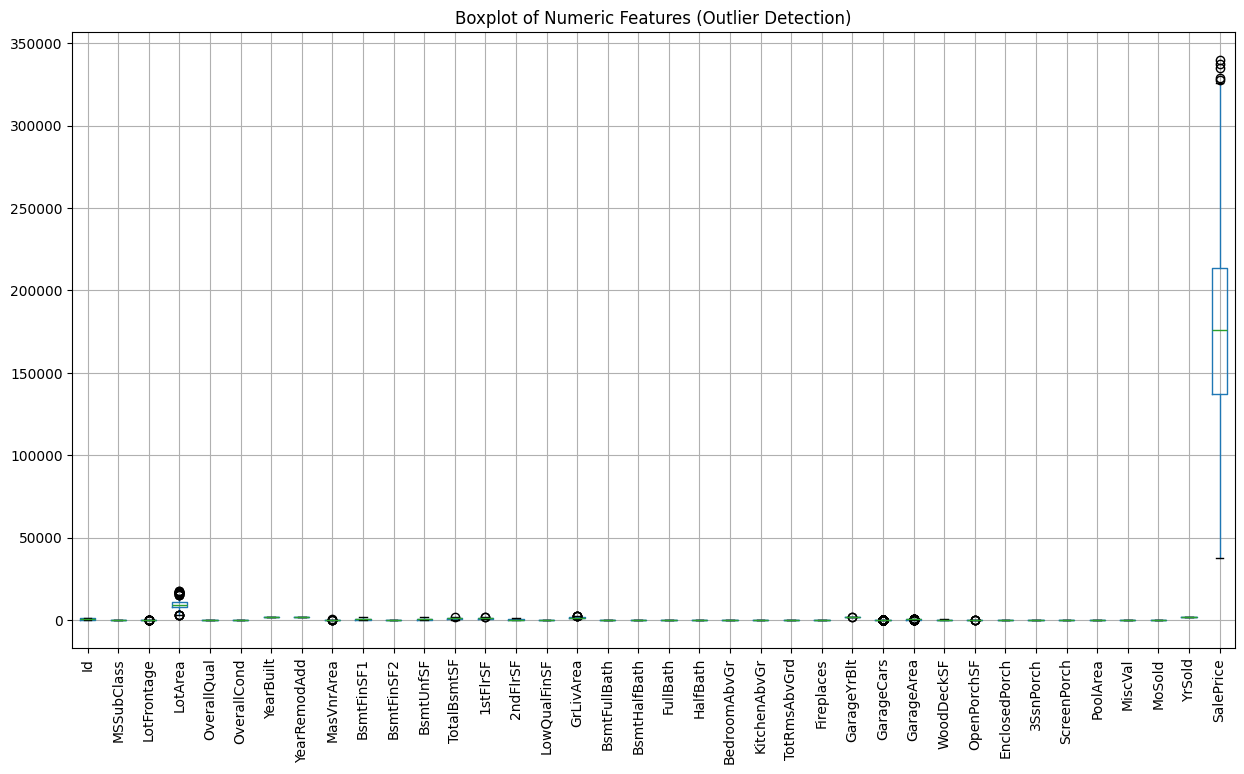

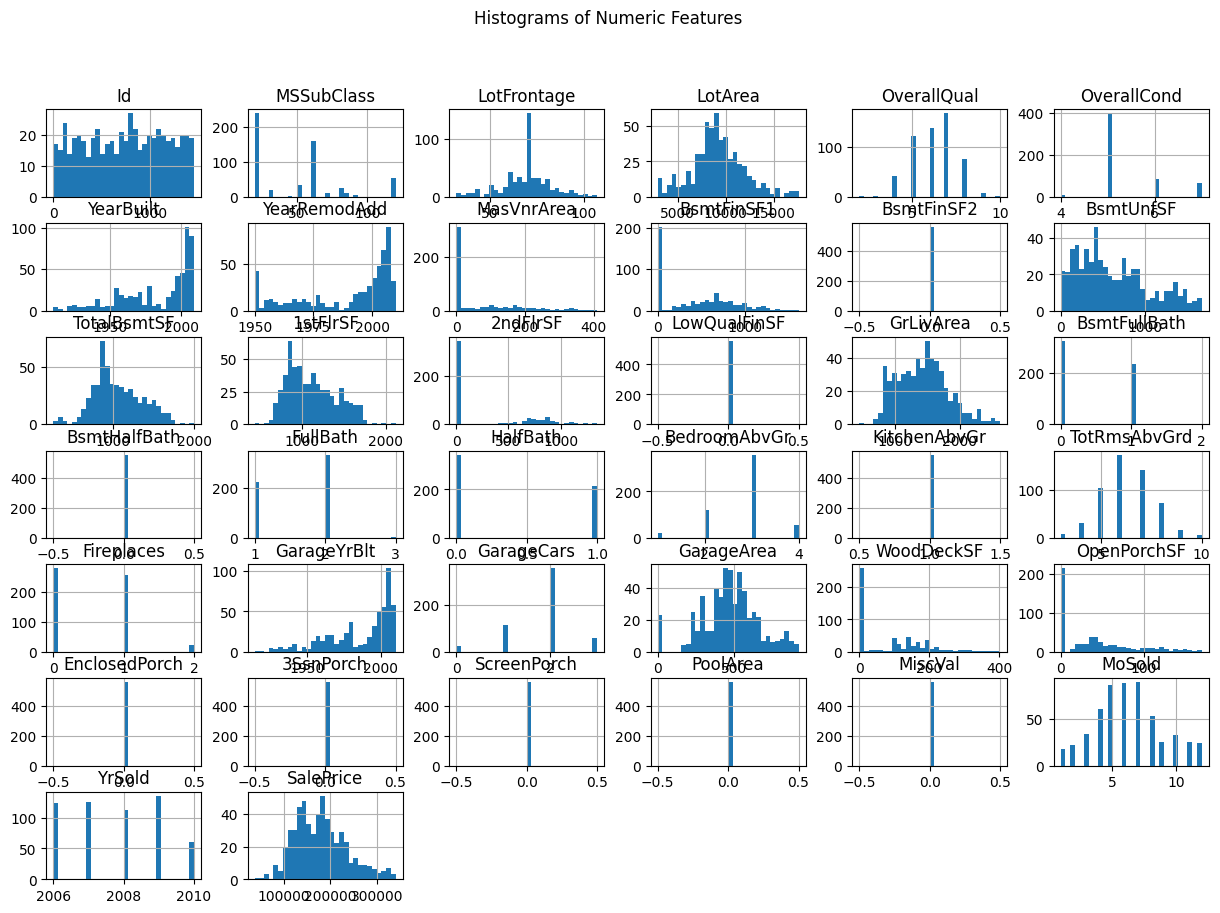

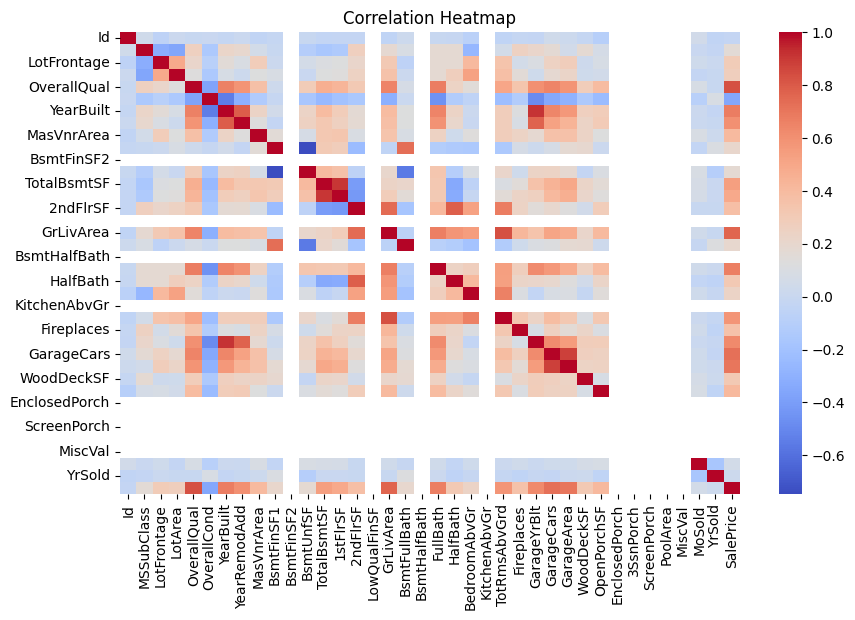

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_train.csv


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0.000000,0.4,RL,0.440000,0.378101,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.090909,0.50,WD,Normal,0.565181
2,0.001375,0.4,RL,0.480000,0.568409,Pave,IR1,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.727273,0.50,WD,Normal,0.614875
4,0.002749,0.4,RL,0.693333,0.772990,Pave,IR1,Lvl,AllPub,FR2,...,0.0,0.0,0.0,0.0,0.0,1.000000,0.50,WD,Normal,0.702667
6,0.004124,0.0,RL,0.573333,0.489159,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.636364,0.25,WD,Normal,0.891502
10,0.006873,0.0,RL,0.506667,0.565011,Pave,Reg,Lvl,AllPub,Inside,...,0.0,0.0,0.0,0.0,0.0,0.090909,0.50,WD,Normal,0.303462


In [4]:
# Cleaning process

def data_overview(df):
    # Count missing values
    missing = df.isnull().sum()
    print("\n--- Missing Values ---")
    print(missing)

    if(missing.sum() > 0):
        # Filter columns with missing values
        missing = missing[missing > 0].sort_values(ascending=False)

        # Plot bar chart
        plt.figure(figsize=(12,6))
        missing.plot(kind='bar')

        plt.title('Missing Values per Column')
        plt.xlabel('Features')
        plt.ylabel('Number of Missing Values')

        plt.show()
        
    print("\n--- Duplicate Rows ---")
    print(df.duplicated().sum().sum())

    return df

# =========================
# Handle Missing Values
# =========================
def handle_missing_values(df):

    # 1. Replace common fake missing values with actual NaN
    df = df.replace(
    ["NA", "N/A", "null", "?", "", "None", "nan", "NaN", " "],
    np.nan)
    

    # 2. Drop columns with more than 50% missing values
    threshold = len(df) * 0.5
    df = df.dropna(thresh=threshold, axis=1)

    # 3. Attempt to convert columns to numeric where possible
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='ignore')

    # Identify numeric and categorical columns
    num_cols = df.select_dtypes(include=np.number).columns
    cat_cols = df.select_dtypes(include='object').columns

    # 4. Fill missing values in numeric columns with mean
    df.loc[:, num_cols] = df[num_cols].fillna(df[num_cols].mean())

    # 5. Fill missing values in categorical columns
    for col in cat_cols:
        if df[col].mode().empty:
            # If no mode exists (all values are NaN), fill with placeholder
            df.loc[:, col] = df[col].fillna("Unknown")
        else:
            # Fill with most frequent value
            df.loc[:, col] = df[col].fillna(df[col].mode()[0])
    
    # 7. Final check: drop any remaining missing values
    df = df.dropna()

    # Print remaining missing values (should be zero)
    print("Remaining missing values:", df.isnull().sum().sum())

    return df

# =========================
# Remove Duplicates
# =========================
def remove_duplicates(df):
    df = df.drop_duplicates()
    print("Duplicates removed.")
    return df


# =========================
# Fix Data Types
# =========================
def fix_data_types(df):
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

    print("Data types fixed.")
    return df


# =========================
# Handle Outliers (IQR)
# =========================
def remove_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    mask = pd.Series(True, index=df.index)

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= df[col].between(lower_bound, upper_bound)

    df_cleaned = df[mask]

    print(f"Outliers removed. Remaining rows: {len(df_cleaned)}")
    return df_cleaned


def visualize_outliers(df):
    num_cols = df.select_dtypes(include=np.number).columns

    # 1. Boxplot
    plt.figure(figsize=(15, 8))
    df[num_cols].boxplot(rot=90)
    plt.title("Boxplot of Numeric Features (Outlier Detection)")
    plt.show()

    # 2. Histogram
    df[num_cols].hist(figsize=(15, 10), bins=30)
    plt.suptitle("Histograms of Numeric Features")
    plt.show()

    # 3. Heatmap correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[num_cols].corr(), cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap")
    plt.show()
    
# =========================
# Normalize Data
# =========================
def normalize_data(df):
    num_cols = df.select_dtypes(include=np.number).columns

    min_vals = df[num_cols].min()
    max_vals = df[num_cols].max()

    denom = (max_vals - min_vals).replace(0, 1)

    df[num_cols] = (df[num_cols] - min_vals) / denom

    print("Data normalized safely.")
    return df

# =========================
# Full Pipeline
# =========================
def clean_data_pipeline(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)
    df = normalize_data(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df = clean_data_pipeline(train, '/kaggle/working/cleaned_data_train.csv')

# Preview
cleaned_df.head()

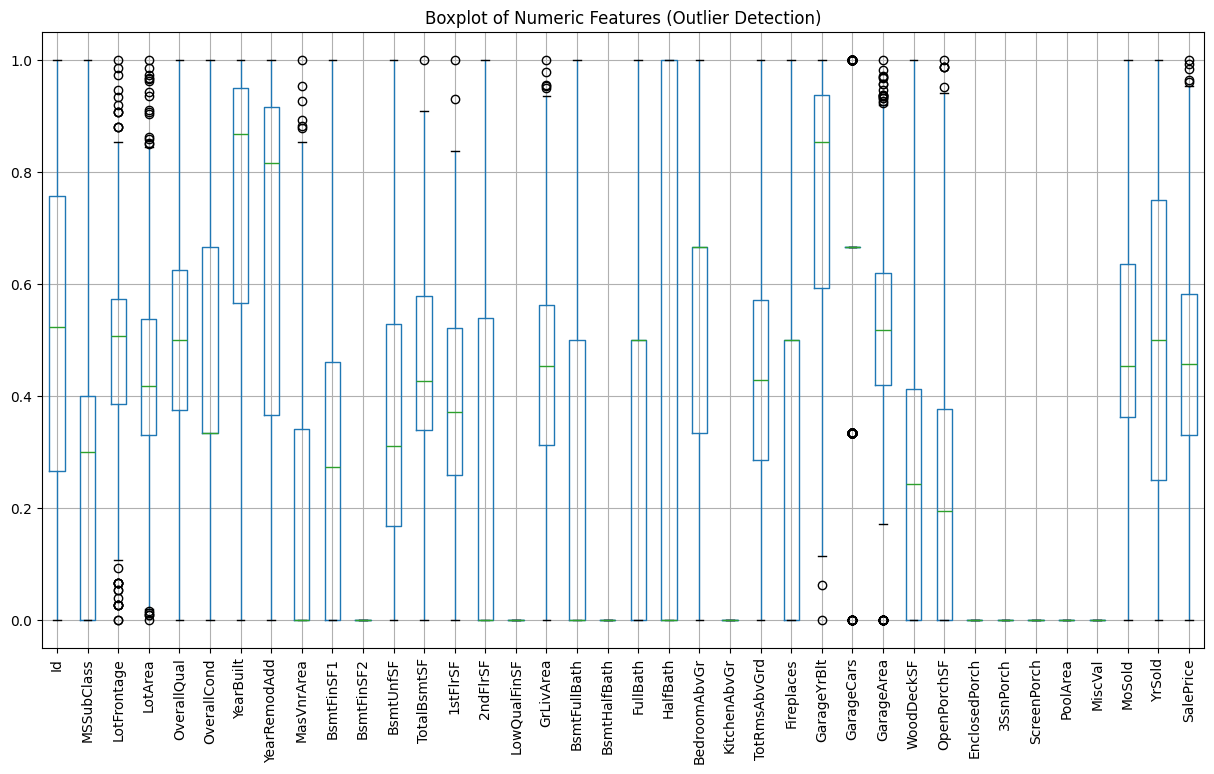

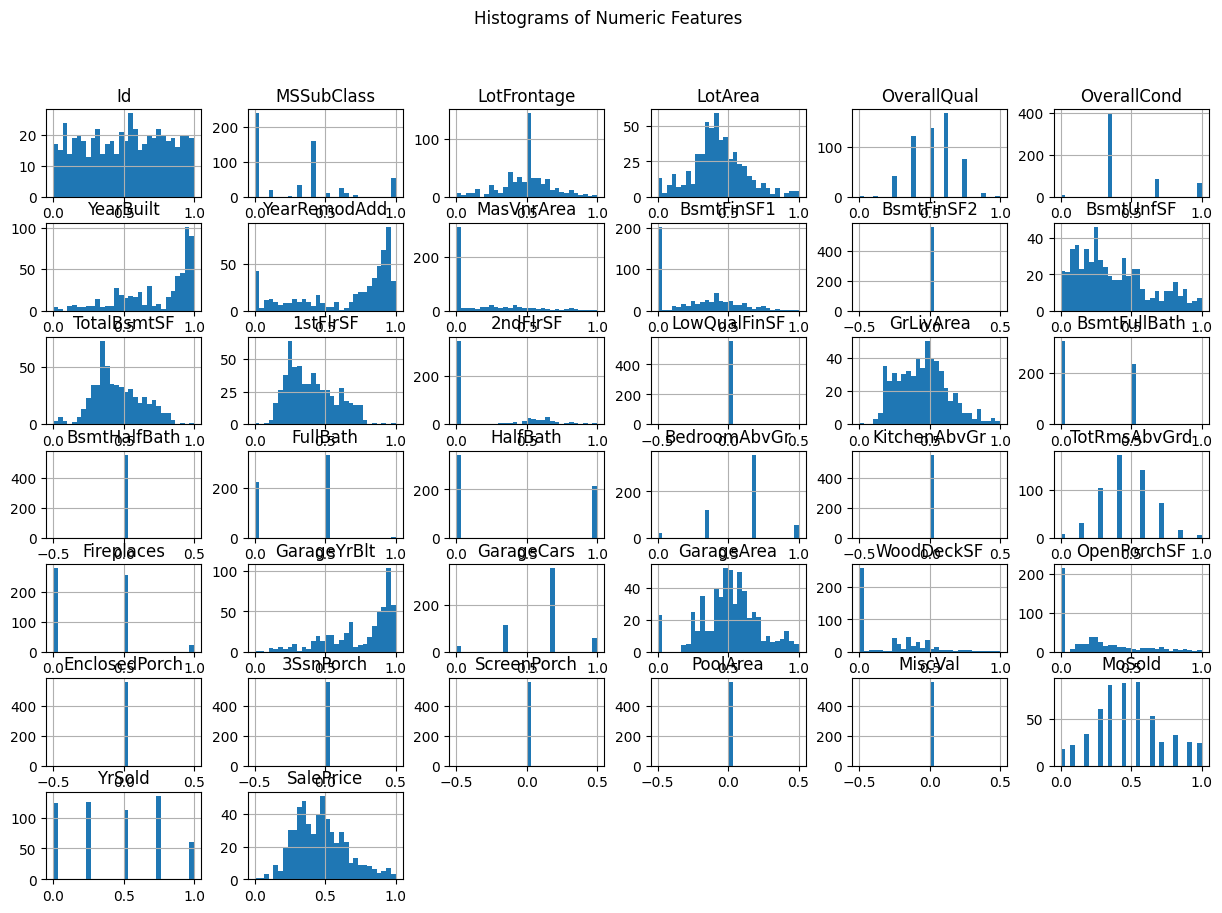

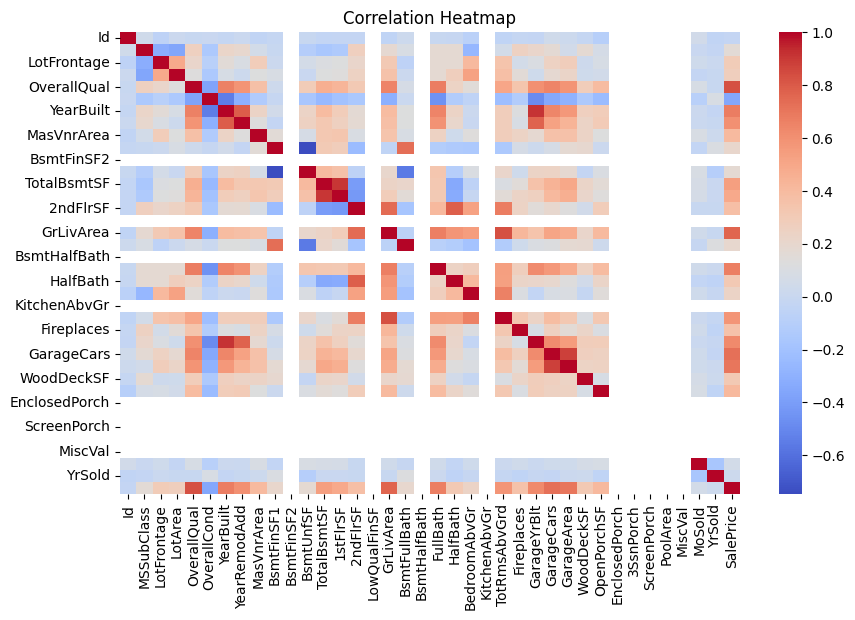

In [5]:
visualize_outliers(cleaned_df)


--- Missing Values ---
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


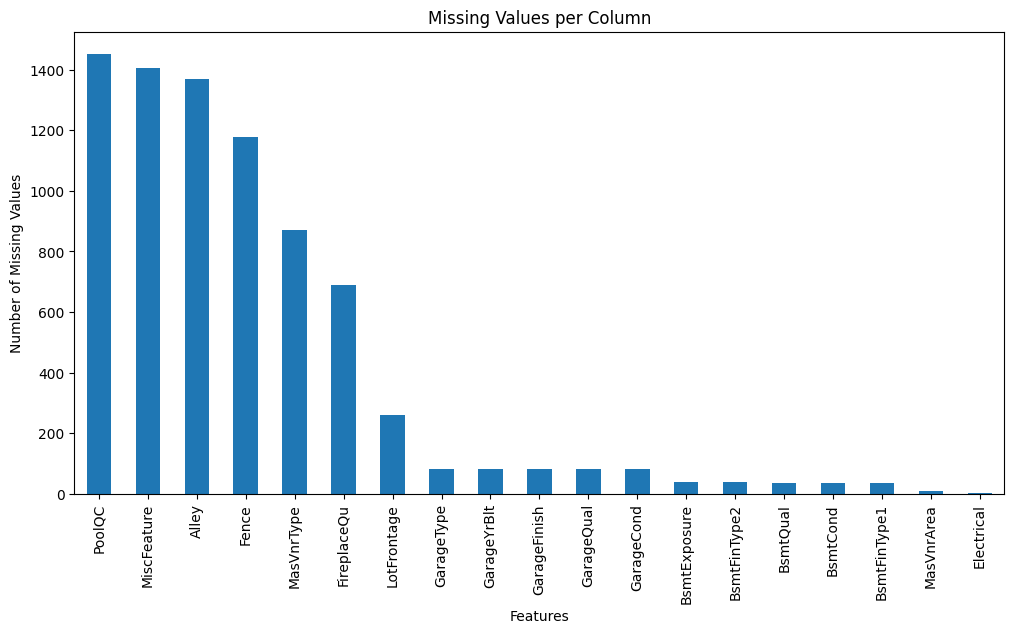


--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_16/3541617771.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


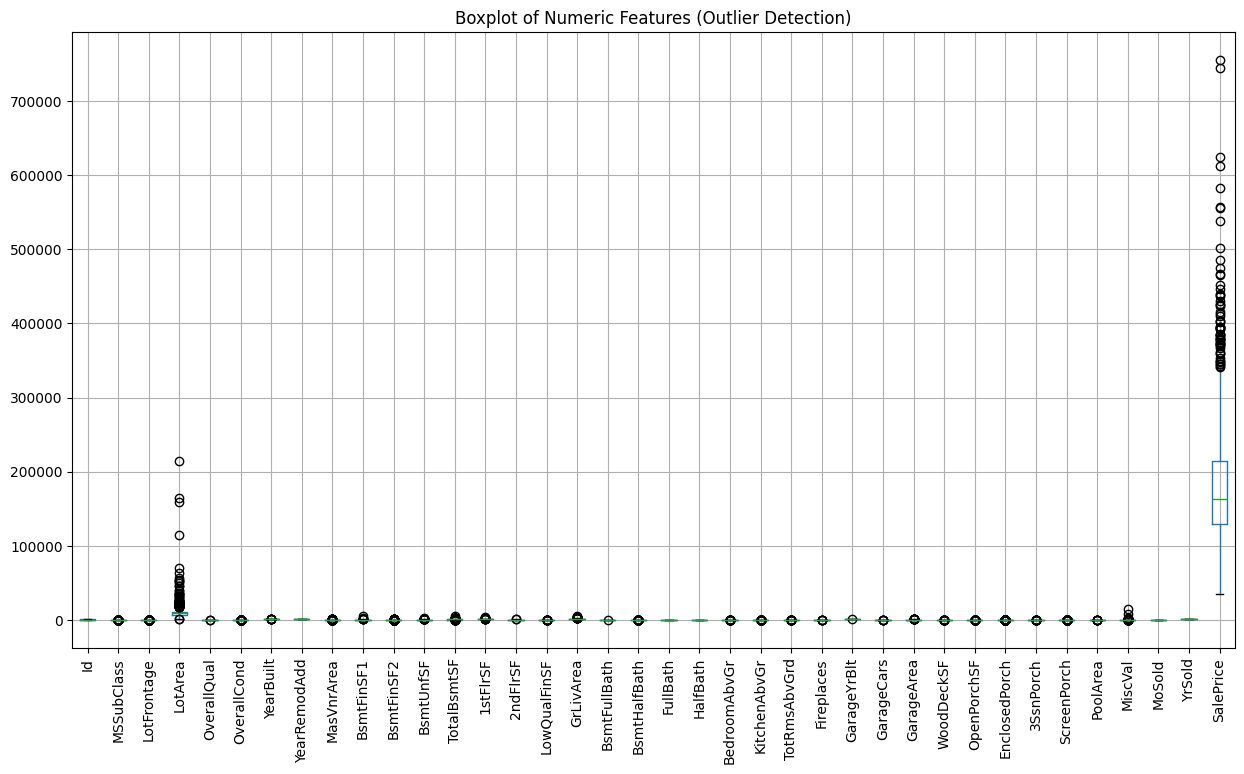

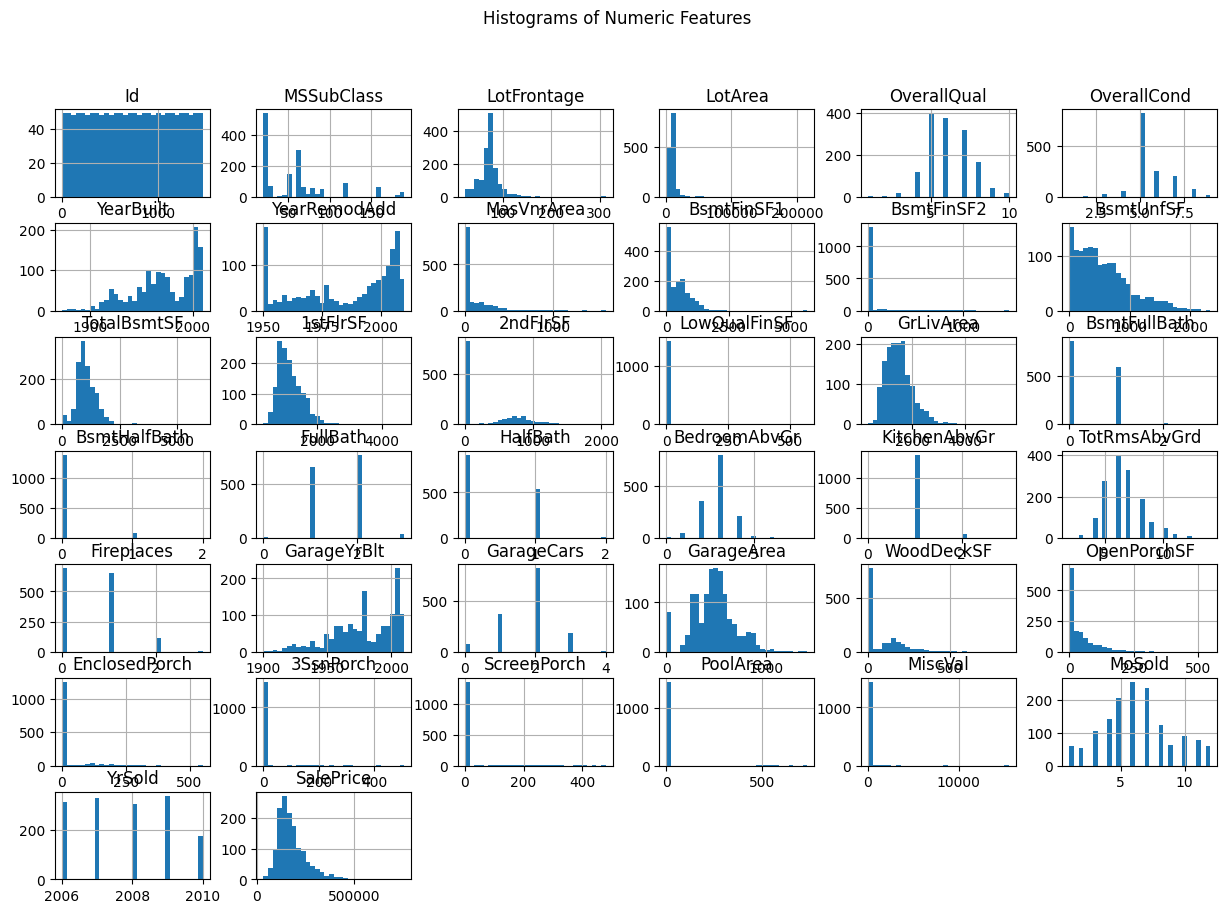

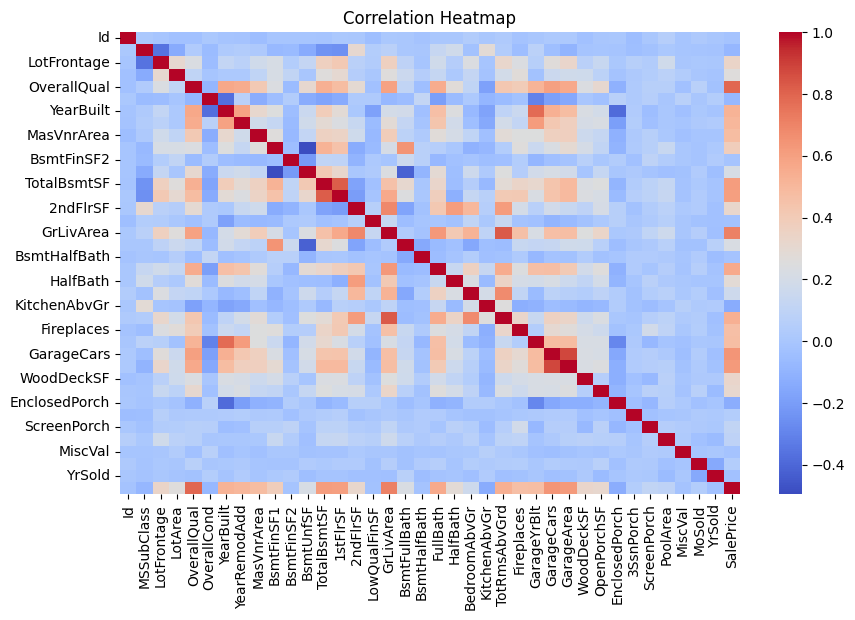

Outliers removed. Remaining rows: 557
After removing outliers:


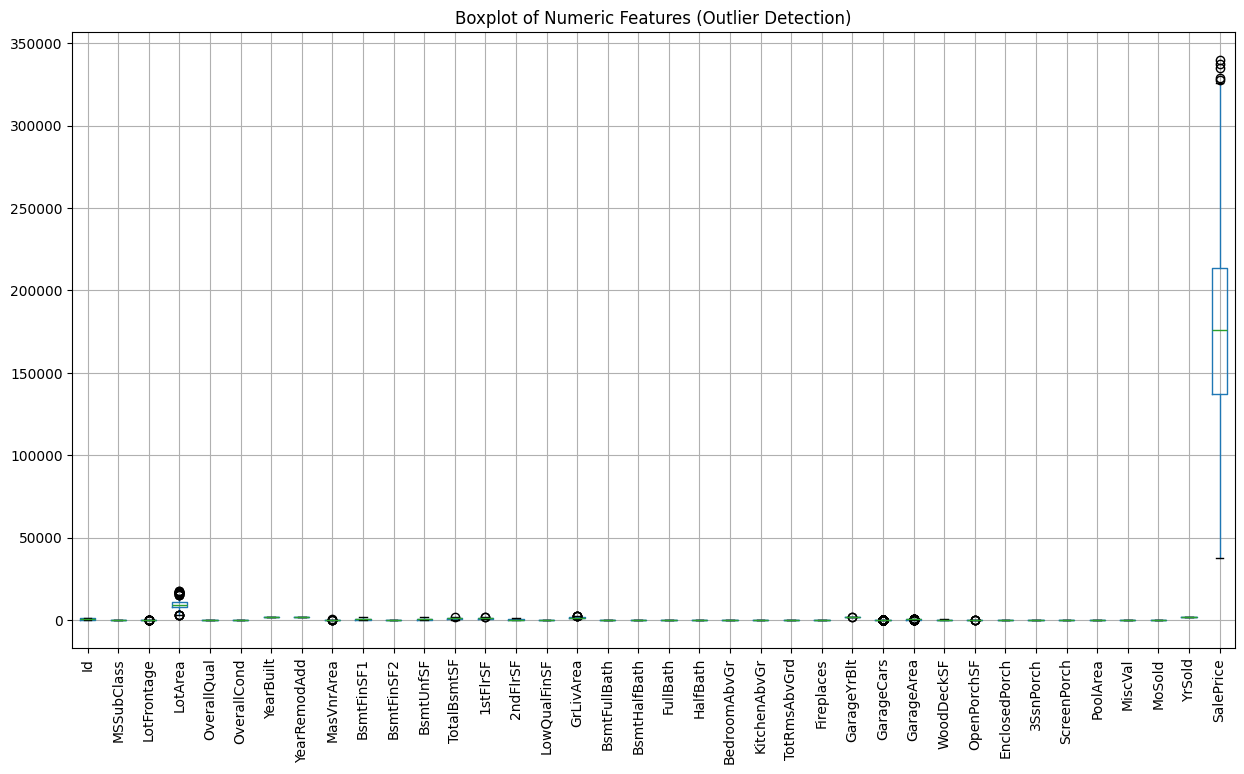

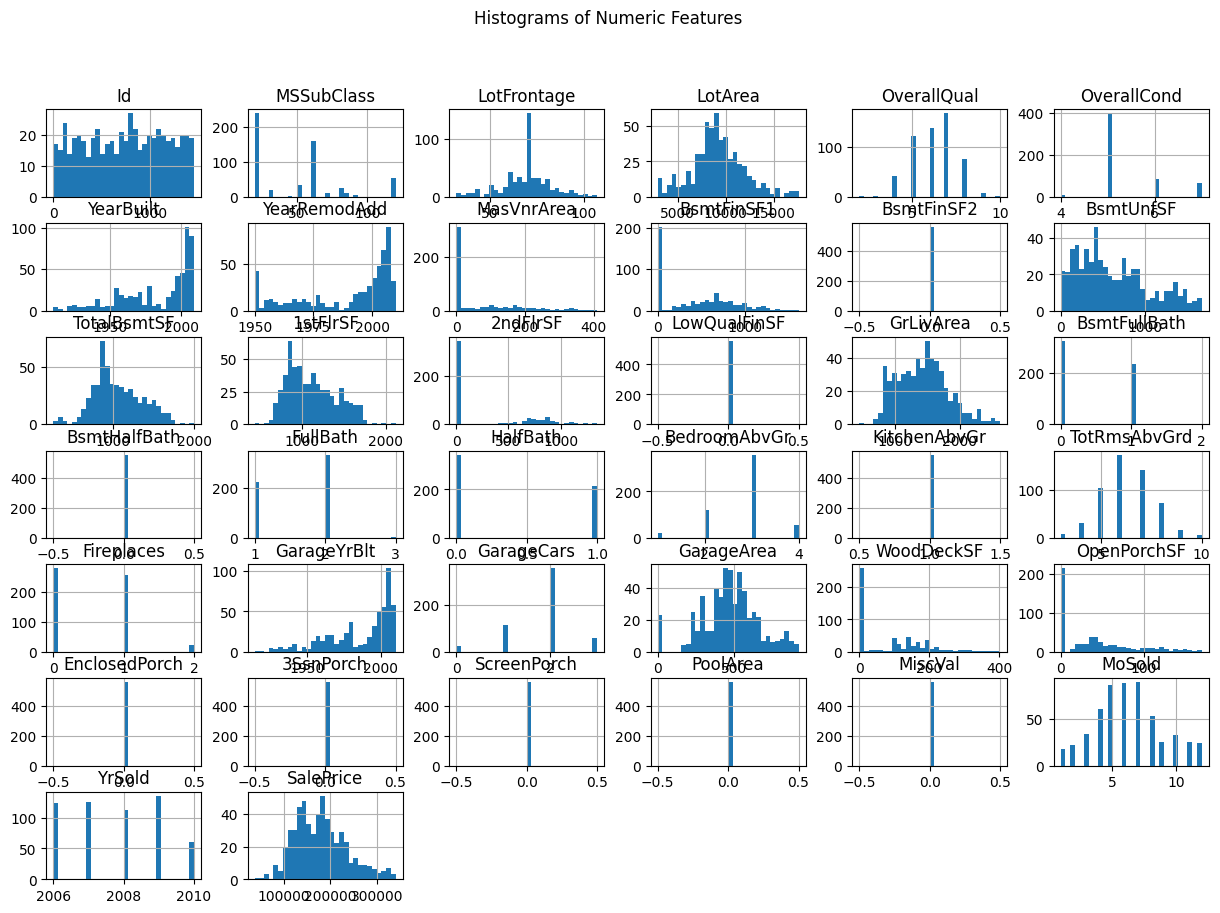

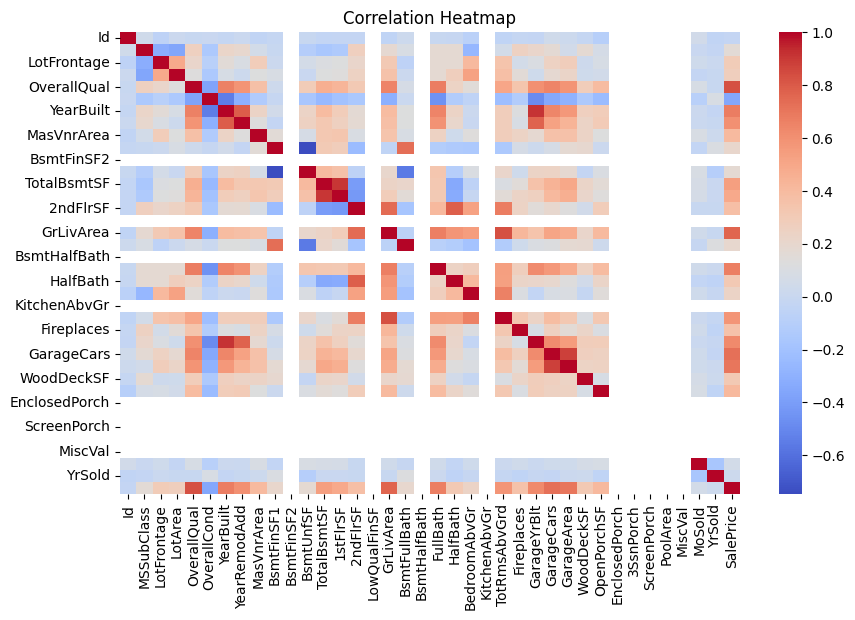

Cleaned data saved to /kaggle/working/cleaned_data_train2.csv


In [6]:
# =========================
# Full Pipeline
# =========================
def clean_data_pipeline_withoutNormalized(df, save_path=None):
    df = data_overview(df)
    df = handle_missing_values(df)
    df = remove_duplicates(df)
    df = fix_data_types(df)
    print('Before removing outliers:')
    visualize_outliers(df)
    df = remove_outliers(df)
    print('After removing outliers:')
    visualize_outliers(df)

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"Cleaned data saved to {save_path}")

    return df


cleaned_df2 = clean_data_pipeline_withoutNormalized(train, '/kaggle/working/cleaned_data_train2.csv')


--- Missing Values ---
Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64


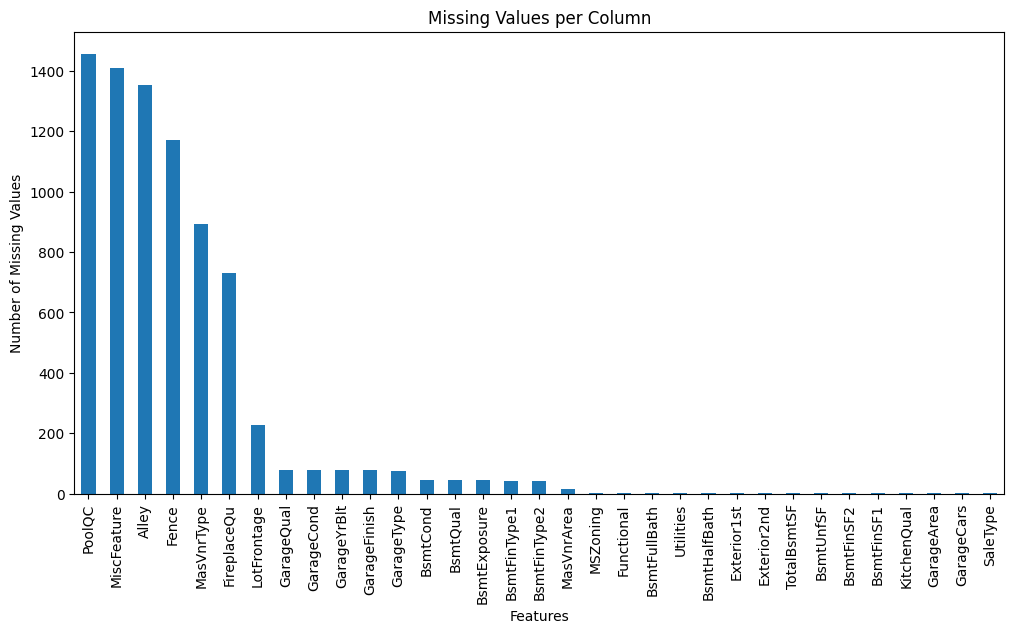


--- Duplicate Rows ---
0
Remaining missing values: 0
Duplicates removed.
Data types fixed.
Before removing outliers:


/tmp/ipykernel_16/3541617771.py:45: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


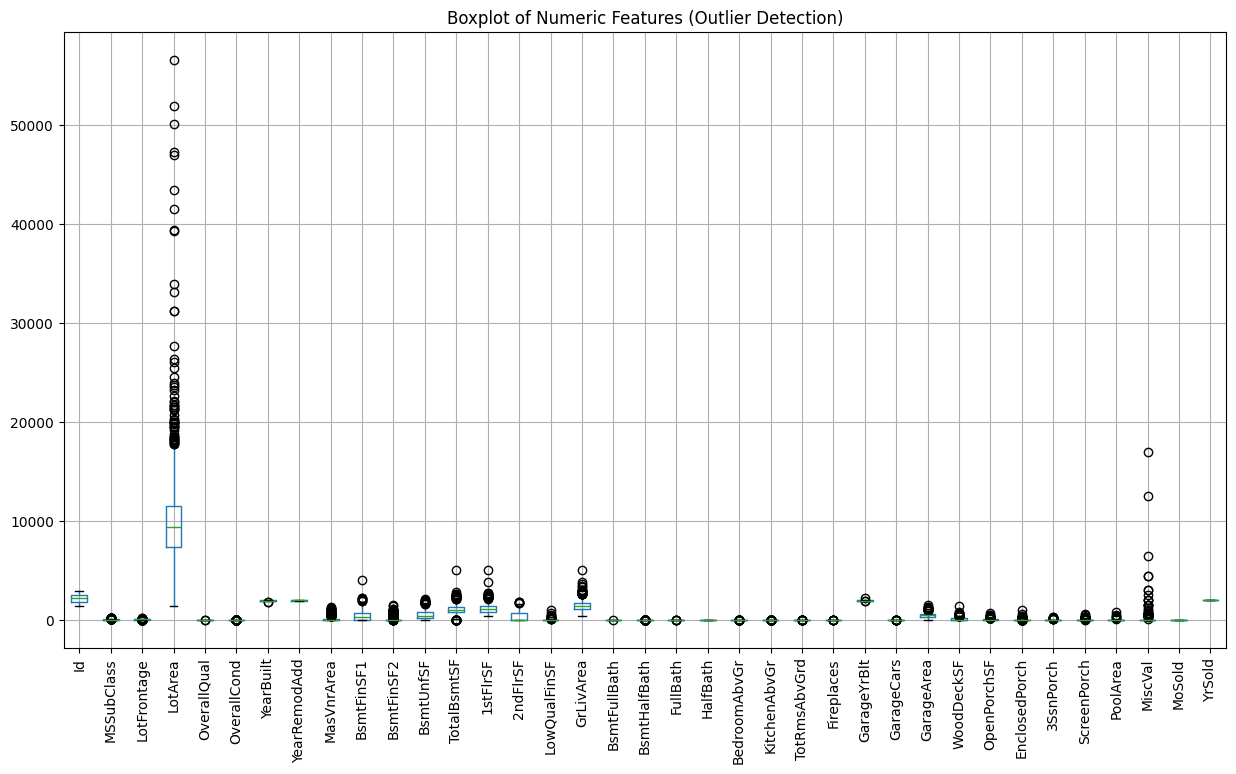

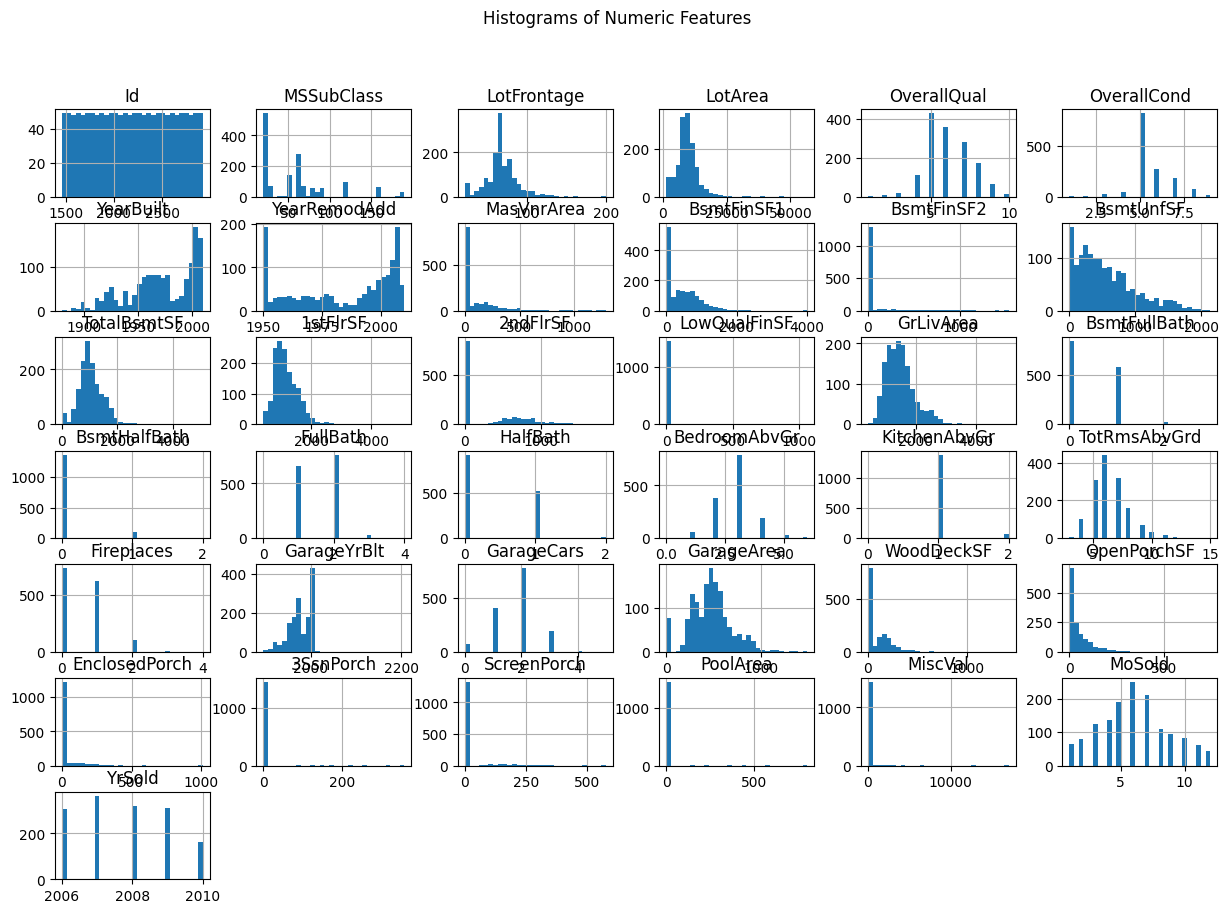

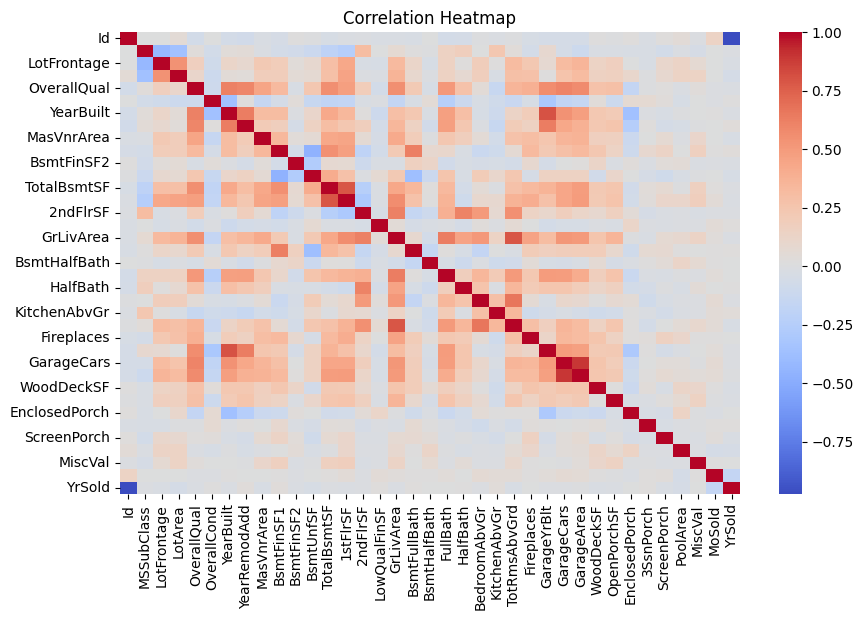

Outliers removed. Remaining rows: 543
After removing outliers:


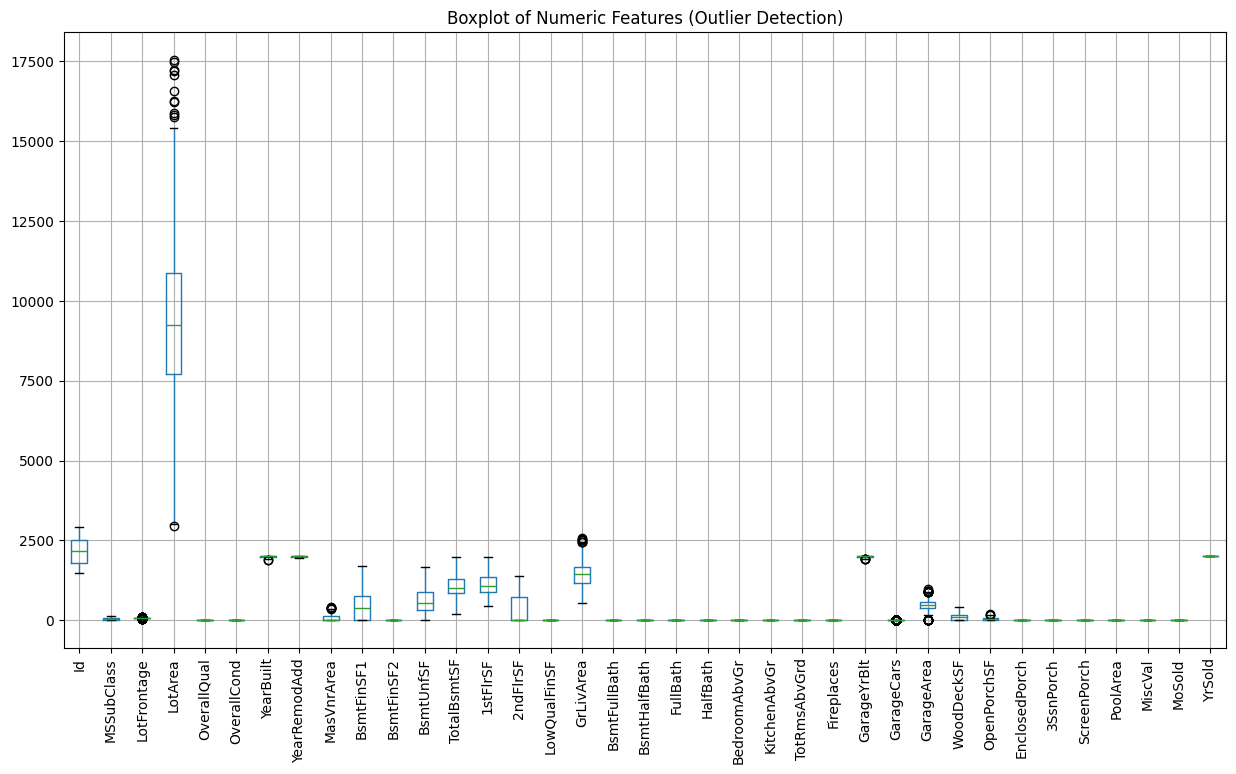

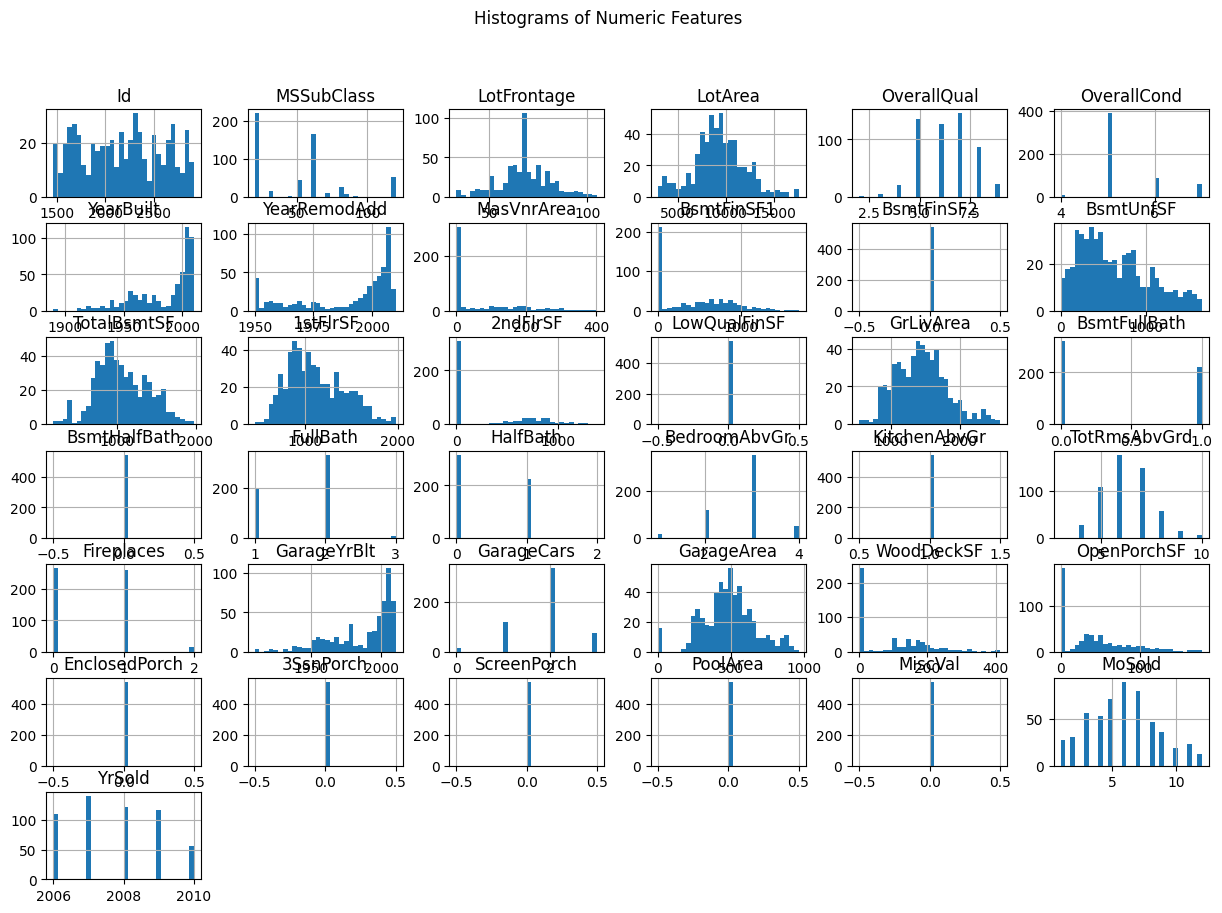

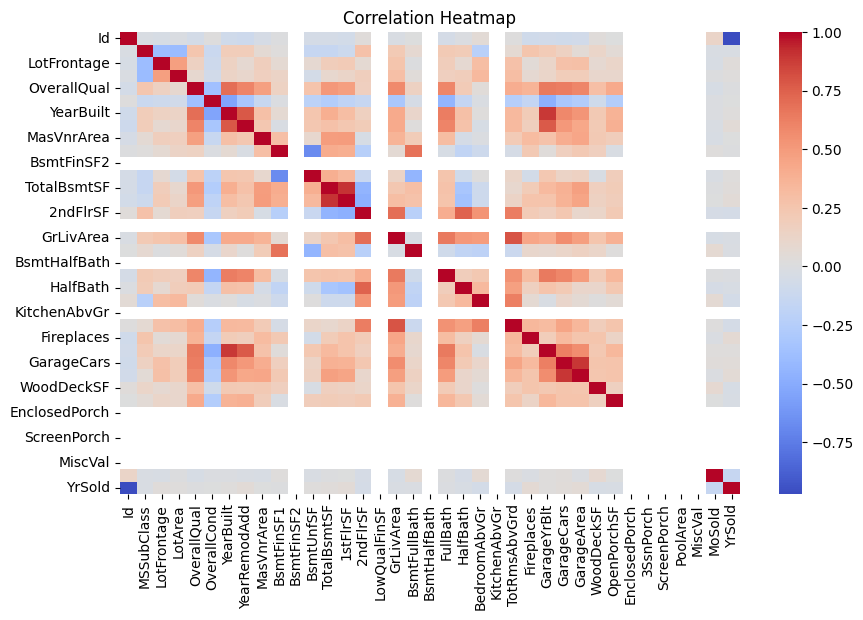

Data normalized safely.
Cleaned data saved to /kaggle/working/cleaned_data_test.csv


In [7]:
cleaned_test_df = clean_data_pipeline(test, '/kaggle/working/cleaned_data_test.csv')
df_train = cleaned_df
df_test = cleaned_test_df

In [8]:
print(df_train.columns)

#Feature Engineering Train Data

#Time Features
df_train["HouseAge"] = df_train["YrSold"] - df_train["YearBuilt"]
df_train["RemodAge"] = df_train["YrSold"] - df_train["YearRemodAdd"]
df_train["GarageAge"] = df_train["YrSold"] - df_train["GarageYrBlt"]

df_train["IsRemodeled"] = (df_train["YearRemodAdd"] != df_train["YearBuilt"]).astype(int)

#Space Features
df_train["TotalSF"] = df_train["TotalBsmtSF"] + df_train["1stFlrSF"] + df_train["2ndFlrSF"]
df_train["TotalPorchSF"] = df_train["OpenPorchSF"] + df_train["EnclosedPorch"] + df_train["3SsnPorch"] + df_train["ScreenPorch"]
df_train["TotalBathrooms"] = (
    df_train["FullBath"] +
    0.5 * df_train["HalfBath"] +
    df_train["BsmtFullBath"] +
    0.5 * df_train["BsmtHalfBath"]
)

#Quality Features
df_train["OverallQualityScore"] = (
    df_train["OverallQual"] * df_train["OverallCond"]
)

#Location Features
neigh_price = df_train.groupby("Neighborhood")["SalePrice"].mean()
df_train["NeighborhoodPrice"] = df_train["Neighborhood"].map(neigh_price)
#Maybe clustering can give us better result for this

#Home Features
df_train["BsmtFinRatio"] = df_train["BsmtFinSF1"] / (df_train["TotalBsmtSF"] + 1)
df_train["HasBasement"] = (df_train["TotalBsmtSF"] > 0).astype(int)

df_train["GarageScore"] = df_train["GarageCars"] * df_train["GarageArea"]
df_train["HasGarage"] = (df_train["GarageArea"] > 0).astype(int)

df_train["LotAreaLog"] = np.log1p(df_train["LotArea"])
df_train["LotFrontageRatio"] = df_train["LotFrontage"] / (df_train["LotArea"] + 1)

df_train["HasPool"] = (df_train["PoolArea"] > 0).astype(int)
df_train["HasFireplace"] = (df_train["Fireplaces"] > 0).astype(int)
df_train["Has2ndFloor"] = (df_train["2ndFlrSF"] > 0).astype(int)

#Interaction Features
df_train["Qual_x_SF"] = df_train["OverallQual"] * df_train["GrLivArea"]
df_train["Age_x_Qual"] = df_train["HouseAge"] * df_train["OverallQual"]
df_train["Garage_x_Qual"] = df_train["GarageArea"] * df_train["OverallQual"]

#Nonlinear Transformations
df_train["GrLivArea_log"] = np.log1p(df_train["GrLivArea"])
df_train["TotalSF_sqrt"] = np.sqrt(df_train["TotalSF"])

#Relative Features
df_train["Rel_GrLivArea"] = df_train["GrLivArea"] / df_train.groupby("Neighborhood")["GrLivArea"].transform("mean")

#Rarity Encoding
freq = df_train["Neighborhood"].value_counts()
df_train["NeighborhoodFreq"] = df_train["Neighborhood"].map(freq)

#Outlier-aware Feature
df_train["IsLuxury"] = (df_train["GrLivArea"] > df_train["GrLivArea"].quantile(0.9)).astype(int)



Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
       'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces',
       'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish',
       'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenP

In [9]:
#Feature Engineering Test Data

# Time Features
df_test["HouseAge"] = df_test["YrSold"] - df_test["YearBuilt"]
df_test["RemodAge"] = df_test["YrSold"] - df_test["YearRemodAdd"]
df_test["GarageAge"] = df_test["YrSold"] - df_test["GarageYrBlt"]

df_test["IsRemodeled"] = (df_test["YearRemodAdd"] != df_test["YearBuilt"]).astype(int)

# Space Features
df_test["TotalSF"] = df_test["TotalBsmtSF"] + df_test["1stFlrSF"] + df_test["2ndFlrSF"]

df_test["TotalPorchSF"] = (
    df_test["OpenPorchSF"] +
    df_test["EnclosedPorch"] +
    df_test["3SsnPorch"] +
    df_test["ScreenPorch"]
)

df_test["TotalBathrooms"] = (
    df_test["FullBath"] +
    0.5 * df_test["HalfBath"] +
    df_test["BsmtFullBath"] +
    0.5 * df_test["BsmtHalfBath"]
)

# Quality Features
df_test["OverallQualityScore"] = df_test["OverallQual"] * df_test["OverallCond"]

# Location Features (IMPORTANT: use TRAIN mapping)
df_test["NeighborhoodPrice"] = df_test["Neighborhood"].map(neigh_price)

# Home Features
df_test["BsmtFinRatio"] = df_test["BsmtFinSF1"] / (df_test["TotalBsmtSF"] + 1)
df_test["HasBasement"] = (df_test["TotalBsmtSF"] > 0).astype(int)

df_test["GarageScore"] = df_test["GarageCars"] * df_test["GarageArea"]
df_test["HasGarage"] = (df_test["GarageArea"] > 0).astype(int)

df_test["LotAreaLog"] = np.log1p(df_test["LotArea"])
df_test["LotFrontageRatio"] = df_test["LotFrontage"] / (df_test["LotArea"] + 1)

df_test["HasPool"] = (df_test["PoolArea"] > 0).astype(int)
df_test["HasFireplace"] = (df_test["Fireplaces"] > 0).astype(int)
df_test["Has2ndFloor"] = (df_test["2ndFlrSF"] > 0).astype(int)

# Interaction Features
df_test["Qual_x_SF"] = df_test["OverallQual"] * df_test["GrLivArea"]
df_test["Age_x_Qual"] = df_test["HouseAge"] * df_test["OverallQual"]
df_test["Garage_x_Qual"] = df_test["GarageArea"] * df_test["OverallQual"]

# Nonlinear Transformations
df_test["GrLivArea_log"] = np.log1p(df_test["GrLivArea"])
df_test["TotalSF_sqrt"] = np.sqrt(df_test["TotalSF"])

# Relative Features
neigh_mean_grliv = df_train.groupby("Neighborhood")["GrLivArea"].mean()

df_test["Rel_GrLivArea"] = (
    df_test["GrLivArea"] / df_test["Neighborhood"].map(neigh_mean_grliv)
)

# Rarity Encoding
freq = df_train["Neighborhood"].value_counts()
df_test["NeighborhoodFreq"] = df_test["Neighborhood"].map(freq)

# Outlier-aware Feature
lux_threshold = df_train["GrLivArea"].quantile(0.9)
df_test["IsLuxury"] = (df_test["GrLivArea"] > lux_threshold).astype(int)

In [10]:
#Feature Selection

X = df_train.drop(["SalePrice", "Id"], axis=1)
y = df_train["SalePrice"]

X = pd.get_dummies(X)

#Lasso (Sparse Selection)
lasso = Lasso(alpha=0.001)
lasso.fit(X, y)

lasso_selected = X.columns[lasso.coef_ != 0]

#Mutual Information
mi = mutual_info_regression(X, y)
mi_scores = pd.Series(mi, index=X.columns)

mi_selected = mi_scores[mi_scores > mi_scores.mean()].index

#Tree-based Importance
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

rf_importance = pd.Series(rf.feature_importances_, index=X.columns)
rf_selected = rf_importance[rf_importance > rf_importance.mean()].index

#SHAP
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap_importance = np.abs(shap_values).mean(axis=0)
shap_selected = X.columns[shap_importance > shap_importance.mean()]

#Hybrid Selection
weights = {
    "lasso": 1,
    "mi": 1,
    "rf": 2,
    "shap": 3
}

scores = {}

for f in X.columns:
    scores[f] = 0
    if f in lasso_selected: scores[f] += weights["lasso"]
    if f in mi_selected: scores[f] += weights["mi"]
    if f in rf_selected: scores[f] += weights["rf"]
    if f in shap_selected: scores[f] += weights["shap"]

final_features = [f for f, s in scores.items() if s >= 3]
print(final_features)

['OverallQual', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'FullBath', 'GarageYrBlt', 'TotalSF', 'TotalBathrooms', 'OverallQualityScore', 'NeighborhoodPrice', 'BsmtFinRatio', 'GarageScore', 'Qual_x_SF', 'Garage_x_Qual', 'TotalSF_sqrt', 'Foundation_PConc', 'BsmtQual_Ex', 'BsmtQual_Gd', 'BsmtFinType1_GLQ']


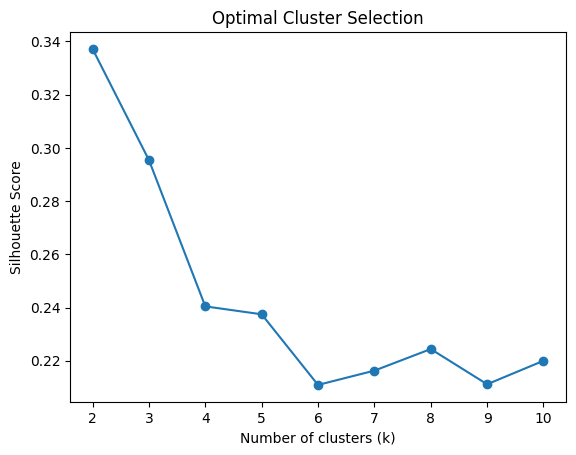

Best k: 2


In [11]:
# Features for clustering
cluster_features = [
    'OverallQual',
    'YearBuilt',
    'YearRemodAdd',
    'BsmtFinSF1',
    'BsmtUnfSF',
    'TotalBsmtSF',
    'FullBath',
    'GarageYrBlt',
    'TotalSF',
    'TotalBathrooms',
    'BsmtFinRatio',
    'GarageScore',
    'TotalSF_sqrt',
    'OverallQualityScore',
    'Qual_x_SF',
    'Garage_x_Qual'
]



# Scale
scaler = StandardScaler()
X_cluster = scaler.fit_transform(df_train[cluster_features])

# Find best k
ks = range(2, 11)
sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    sil_scores.append(score)

# Plot
plt.figure()
plt.plot(ks, sil_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Optimal Cluster Selection")
plt.show()

best_k = ks[np.argmax(sil_scores)]
print("Best k:", best_k)

In [12]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_train["Cluster"] = kmeans.fit_predict(X_cluster)
df_test["Cluster"] = kmeans.predict(scaler.transform(df_test[cluster_features]))

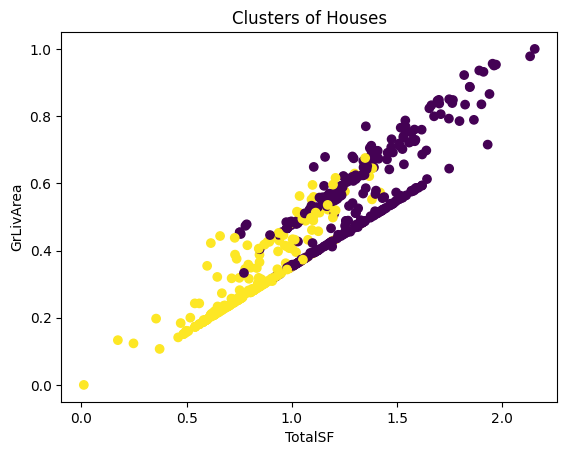

In [13]:
plt.figure()
plt.scatter(df_train["TotalSF"], df_train["GrLivArea"], c=df_train["Cluster"], cmap="viridis")
plt.xlabel("TotalSF")
plt.ylabel("GrLivArea")
plt.title("Clusters of Houses")
plt.show()

In [14]:
final_features = [
    'OverallQual','YearBuilt','YearRemodAdd','BsmtFinSF1',
    'BsmtUnfSF','TotalBsmtSF','FullBath','GarageYrBlt',
    'TotalSF','TotalBathrooms','BsmtFinRatio','GarageScore',
    'TotalSF_sqrt','OverallQualityScore','Qual_x_SF','Garage_x_Qual'
]

cluster_models = {}

In [15]:
for c in df_train["Cluster"].unique():
    
    train_c = df_train[df_train["Cluster"] == c]
    
    X_c = train_c[final_features]
    y_c = np.log1p(train_c["SalePrice"])
    
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
    
    model.fit(X_c, y_c)
    cluster_models[c] = model

In [16]:
preds_cluster = np.zeros(len(df_test))

for c in df_test["Cluster"].unique():
    
    test_c = df_test[df_test["Cluster"] == c]
    preds_cluster[df_test["Cluster"] == c] = np.expm1(
        cluster_models[c].predict(test_c[final_features])
    )

In [17]:
X = df_train.drop(["SalePrice", "Id"], axis=1)
y = df_train["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Stacking Validation:
RMSE: 0.03848430351930706
MAE: 0.024727961081999324
R2: 0.8968805549911799

Hybrid Validation:
RMSE: 0.03848430351930706
MAE: 0.024727961081999324
R2: 0.8968805549911799


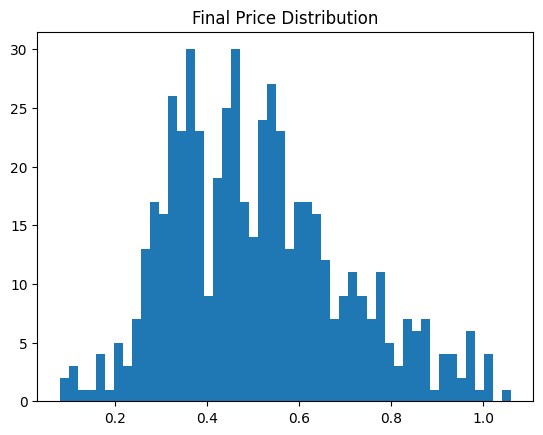

In [18]:
# =========================
# Evaluation function
# =========================
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2


# =========================
# Data preparation
# =========================
X = df_train[final_features]
y = np.log1p(df_train["SalePrice"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# =========================
# Base models
# =========================
ridge = Ridge()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

estimators = [
    ('ridge', ridge),
    ('rf', rf),
    ('xgb', xgb)
]

# =========================
# Stacking model
# =========================
stack_model = StackingRegressor(
    estimators=estimators,
    final_estimator=LinearRegression()
)

# =========================
# Train stacking
# =========================
stack_model.fit(X_train, y_train)

# =========================
# Validation (stacking)
# =========================
pred_stack_val = stack_model.predict(X_val)

rmse, mae, r2 = evaluate(y_val, pred_stack_val)

print("Stacking Validation:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


# =========================
# Cluster model
# =========================

preds_cluster_val = pred_stack_val.copy()

# =========================
# Hybrid (validation)
# =========================
pred_hybrid_val = 0.5 * preds_cluster_val + 0.5 * pred_stack_val

rmse_h, mae_h, r2_h = evaluate(y_val, pred_hybrid_val)

print("\nHybrid Validation:")
print("RMSE:", rmse_h)
print("MAE:", mae_h)
print("R2:", r2_h)


# =========================
# Final training (full data)
# =========================
stack_model.fit(X, y)

# =========================
# Test prediction
# =========================
global_pred = np.expm1(stack_model.predict(df_test[final_features]))

# =========================
# Cluster test (placeholder)
# =========================
preds_cluster = global_pred.copy()

# =========================
# Final hybrid prediction
# =========================
final_pred = 0.5 * preds_cluster + 0.5 * global_pred


# =========================
# Visualization
# =========================
plt.figure()
plt.hist(final_pred, bins=50)
plt.title("Final Price Distribution")
plt.show()

In [19]:
results = {}

# =========================
# 1. Baseline (Ridge only)
# =========================
baseline_model = Ridge()
baseline_model.fit(X_train, y_train)

pred_baseline = baseline_model.predict(X_val)
rmse_baseline = np.sqrt(mean_squared_error(y_val, pred_baseline))

results["Baseline (Ridge)"] = rmse_baseline


# =========================
# 2. Stacking only
# =========================
pred_stack = stack_model.predict(X_val)
rmse_stack = np.sqrt(mean_squared_error(y_val, pred_stack))

results["Stacking"] = rmse_stack


# =========================
# 3. Cluster-only
# =========================
rmse_cluster = np.sqrt(mean_squared_error(y_val, preds_cluster_val))

results["Cluster-only"] = rmse_cluster


# =========================
# 4. Hybrid (final model)
# =========================
pred_hybrid = 0.5 * preds_cluster_val + 0.5 * pred_stack
rmse_hybrid = np.sqrt(mean_squared_error(y_val, pred_hybrid))

results["Hybrid"] = rmse_hybrid


# =========================
# Print results
# =========================
print("Ablation Study Results (RMSE):")
for k, v in results.items():
    print(f"{k}: {v}")

Ablation Study Results (RMSE):
Baseline (Ridge): 0.039140381018887574
Stacking: 0.026936975636140337
Cluster-only: 0.03848430351930706
Hybrid: 0.03250098656415804


In [20]:
error_stack = (y_val - pred_stack) ** 2
error_hybrid = (y_val - pred_hybrid) ** 2

t_stat, p_value = ttest_rel(error_stack, error_hybrid)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.1034352975034536
P-value: 0.03768681512199398


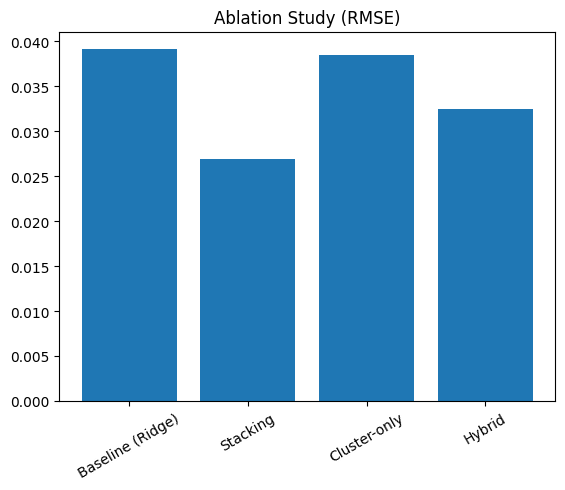

In [21]:
models = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(models, scores)
plt.title("Ablation Study (RMSE)")
plt.xticks(rotation=30)
plt.show()